In [ ]:
import yfinance as yf
symbols = ["AAPL", "MSFT", "GOOG", "AMZN", "JPM"]  # example tickers
data = {sym: yf.download(sym, period="6mo", interval="1d") for sym in symbols}
3

C:\Users\manoj\AppData\Local\Temp\ipykernel_11776\1653339117.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = {sym: yf.download(sym, period="6mo", interval="1d") for sym in symbols}
[*********************100%***********************]  1 of 1 completed
C:\Users\manoj\AppData\Local\Temp\ipykernel_11776\1653339117.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = {sym: yf.download(sym, period="6mo", interval="1d") for sym in symbols}
[*********************100%***********************]  1 of 1 completed
C:\Users\manoj\AppData\Local\Temp\ipykernel_11776\1653339117.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = {sym: yf.download(sym, period="6mo", interval="1d") for sym in symbols}
[*********************100%***********************]  1 of 1 completed
C:\Users\manoj\AppData\Local\Temp\ipykernel_11776\1653339117.py:3: FutureWarning: YF.download() has changed argumen

#Historical data for the past 6 month has been collected for these companies using yfinance.
#AAPL   -  Apple Inc.                   |
#MSFT   -  Microsoft Corp               
#GOOG  -  Alphabet Inc (Google Class C)  
#AMZN   - Amazon.com Inc               
#JPM     JMorgan Chase & Co   

In [ ]:
!pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------------- 949.2/949.2 kB 22.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 43.5 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=6d4a36bfdcdc64b2bc8e55d482cfc319de6d8009a8651866cfb7ccae57f384e7
  Stored in directory: c:\users\manoj\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e663

In [ ]:
# checking for the missing values in the data
for sym, df in data.items():
    print(sym, "missing values:\n", df.isna().sum())


AAPL missing values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
MSFT missing values:
 Price   Ticker
Close   MSFT      0
High    MSFT      0
Low     MSFT      0
Open    MSFT      0
Volume  MSFT      0
dtype: int64
GOOG missing values:
 Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64
AMZN missing values:
 Price   Ticker
Close   AMZN      0
High    AMZN      0
Low     AMZN      0
Open    AMZN      0
Volume  AMZN      0
dtype: int64
JPM missing values:
 Price   Ticker
Close   JPM       0
High    JPM       0
Low     JPM       0
Open    JPM       0
Volume  JPM       0
dtype: int64


In [ ]:
import numpy as np
for sym, df in data.items():
    # Replace infinities with NaN if its found in the data
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows with any missing values
    df.dropna(inplace=True)
    # Remove exact duplicate rows, if any have found in the data we have taken from the yfinance
    df.drop_duplicates(inplace=True)
    data[sym] = df


In [ ]:
# calculating any anomalies in the above fetched data for past 6 months
for sym, df in data.items():
    anomalies = df[(df['Close'] < 0) | (df['Volume'] < 0)]
    print(sym, "anomalous entries:\n", anomalies)


AAPL anomalous entries:
 Price      Close High  Low Open Volume
Ticker      AAPL AAPL AAPL AAPL   AAPL
Date                                  
2025-01-21   NaN  NaN  NaN  NaN    NaN
2025-01-22   NaN  NaN  NaN  NaN    NaN
2025-01-23   NaN  NaN  NaN  NaN    NaN
2025-01-24   NaN  NaN  NaN  NaN    NaN
2025-01-27   NaN  NaN  NaN  NaN    NaN
...          ...  ...  ...  ...    ...
2025-07-14   NaN  NaN  NaN  NaN    NaN
2025-07-15   NaN  NaN  NaN  NaN    NaN
2025-07-16   NaN  NaN  NaN  NaN    NaN
2025-07-17   NaN  NaN  NaN  NaN    NaN
2025-07-18   NaN  NaN  NaN  NaN    NaN

[124 rows x 5 columns]
MSFT anomalous entries:
 Price      Close High  Low Open Volume
Ticker      MSFT MSFT MSFT MSFT   MSFT
Date                                  
2025-01-21   NaN  NaN  NaN  NaN    NaN
2025-01-22   NaN  NaN  NaN  NaN    NaN
2025-01-23   NaN  NaN  NaN  NaN    NaN
2025-01-24   NaN  NaN  NaN  NaN    NaN
2025-01-27   NaN  NaN  NaN  NaN    NaN
...          ...  ...  ...  ...    ...
2025-07-14   NaN  NaN  NaN  N

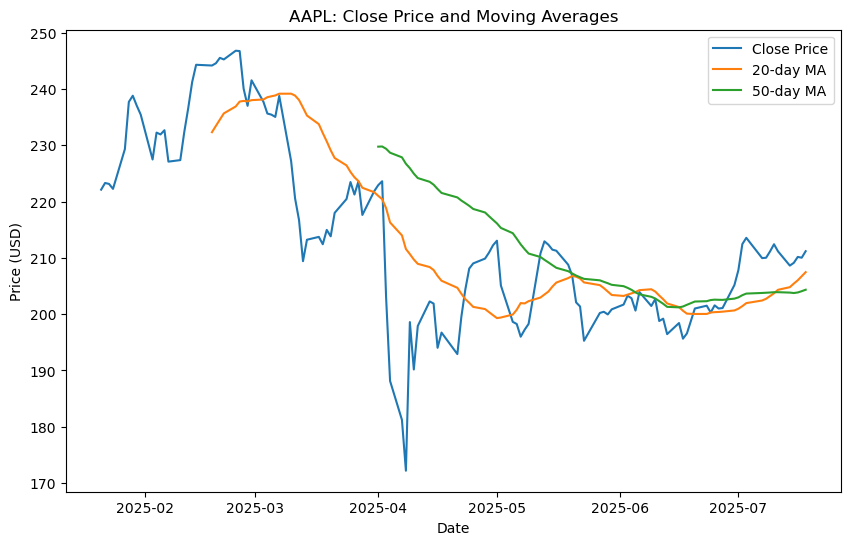

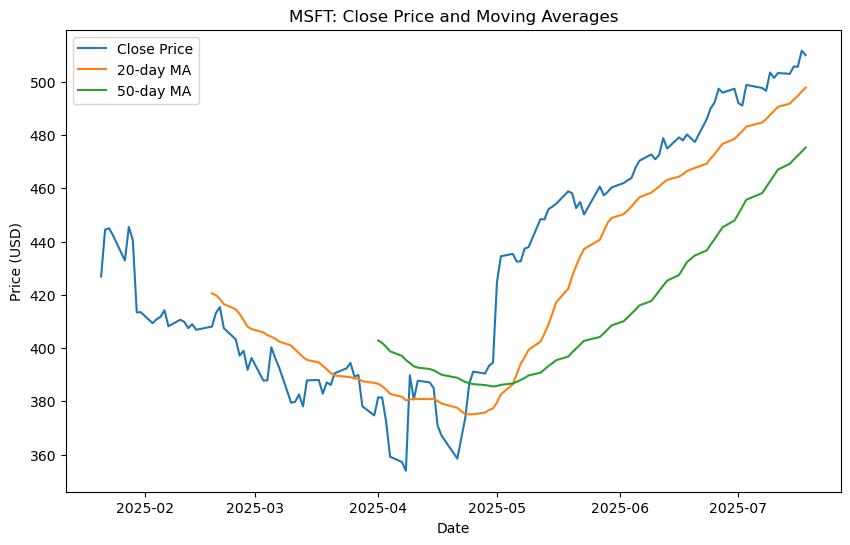

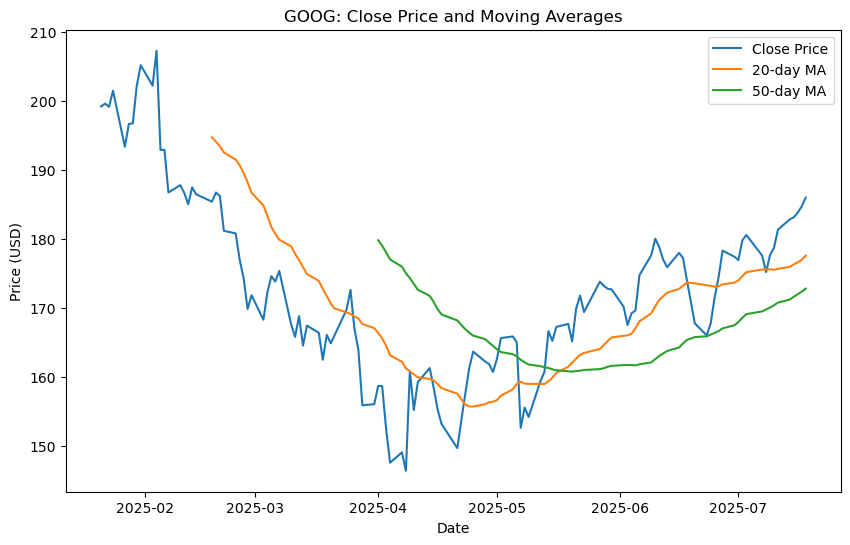

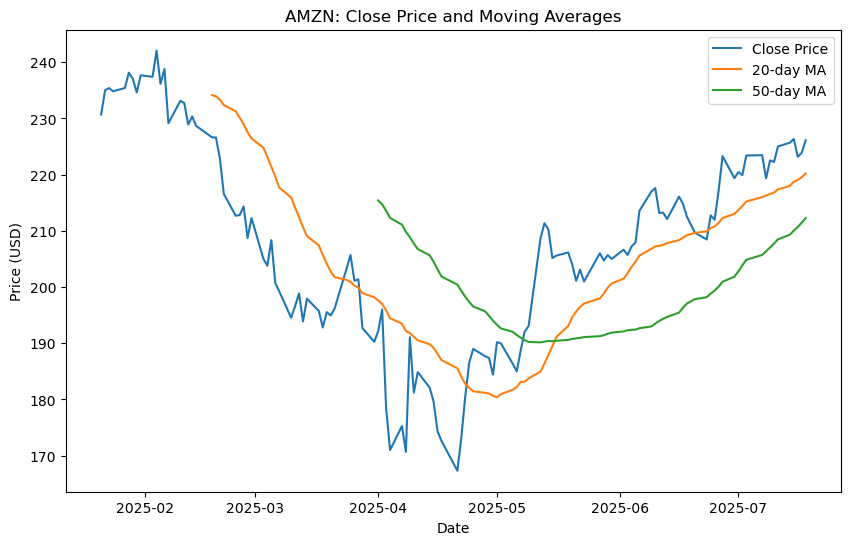

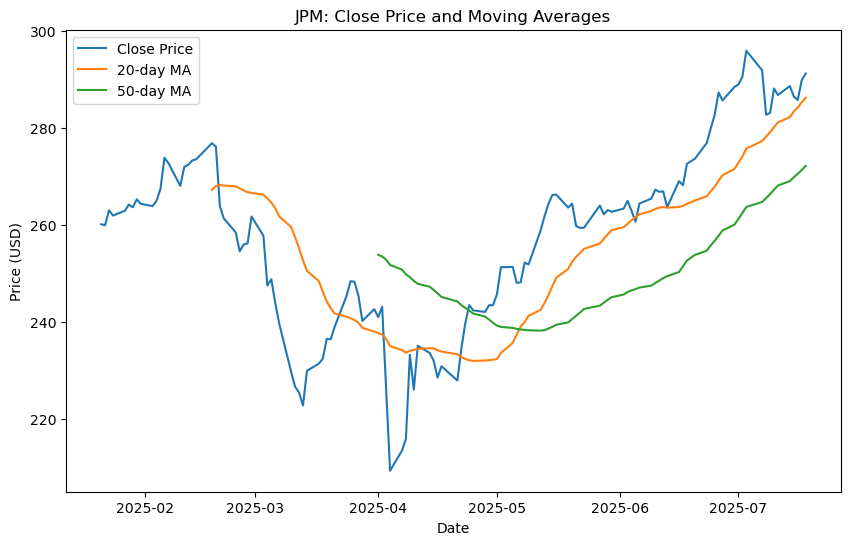

In [ ]:
import matplotlib.pyplot as plt
#calculating the cose price for 6 months and moving average for all companies for 20 and 50 days
for sym, df in data.items():
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    plt.figure(figsize=(10,6))
    plt.plot(df['Close'], label='Close Price')
    plt.plot(df['MA20'], label='20-day MA')
    plt.plot(df['MA50'], label='50-day MA')
    plt.title(f"{sym}: Close Price and Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()


In [ ]:
import seaborn as sns

for sym, df in data.items():
    df['Daily Return'] = df['Close'].pct_change()
    df.dropna(subset=['Daily Return'], inplace=True)
    # Plot histogram of daily returns
    sns.histplot(df['Daily Return'], bins=50, kde=True)
    plt.title(f"{sym}: Daily Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.show()


KeyError: ['Daily Return']